# Principal Components Regression

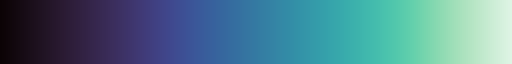

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

sns.color_palette("mako", as_cmap=True)

## Introduction
- Rather than LASSO or fussing around randomly to do feature selection, why not transform the data with PCA, then chose which $L$ of $K$ transformed variables to include as features/covariates?
- This is very clever: For $K$ features/covariates, there are $2^K$ possible choices of subsets of variables, while with PCA, there are only $K$ ways to choose the first $L$ principal components
- Problem: Explainability/Interpretability suffers, because we can't really make sense of what the transformed variables really mean. They're just a technology to make predictions, and rely on the dimensions we dropped. You can use this for prediction-making, but interpreting indices and including them as covariates is not typically a responsible thing to do.

## Outline

1. Orthogonality and Principal Components
2. Principal Components Regression

# 1. Orthogonality and Principal Components

## Dot Products and Angles
- This thing we have been doing throughout the class:
$$
x_1 y_1 + x_2 y_2 + ... + x_L y_L = \sum_{\ell=1}^L x_\ell y_\ell = x \cdot y
$$
is called the **dot product** or **inner product**
- First, it creates **length** of a vector:
$$
||x|| = \sqrt{x \cdot x} = \sqrt{\sum_{\ell=1}^L x_\ell^2 }
$$
- Second, it creates the **angle** $\theta_{xy}$ between vector $x$ and $y$:
$$
\cos(\theta_{xy}) = \dfrac{x \cdot y}{||x|| \times ||y||}
$$

![Angles](./src/angles.png)

## Dot Product and Length: Everywhere
- Covariance is literally a statistical dot product:
$$
\text{cov}(x,y) = \frac{1}{N} \sum_{i=1}^N (x_i - \bar{x})(y_i-\bar{y}) = \frac{(x-\bar{x}) \cdot (y-\bar{y}) }{N}
$$
- Standard Deviation is a literally a statistical length:
$$
s_d = \sqrt{\frac{1}{N}(x_i - \bar{x})^2} = \dfrac{\sqrt{(x-\bar{x})\cdot (x-\bar{x})}}{\sqrt{N}} = \dfrac{||x-\bar{x}||}{\sqrt{N}}
$$
- Correlation is literally a statistical angle:
$$
\text{corr}(x,y) = \frac{\frac{1}{N}(x-\bar{x}) \cdot (y-\bar{y}) }{s_d s_y} = \frac{(x-\bar{x}) \cdot (y-\bar{y}) }{||x-\bar{x}||\times ||y-\bar{y}||} = \cos(\theta_{x-\bar{x},y-\bar{y}})
$$

## Orthogonality: Right Angles
- Two vectors $x$ and $y$ are **orthogonal** if
$$
x \cdot y = 0
$$
- This means they are at a right angle, because if $\cos(\theta_{xy})=0$, then $\theta_{xy}=\pi/2$ or 90 degrees
- The archetypal orthogonal vectors are $(1,0)$ and $(0,1)$, for which 
$1*0 +0*1 = 0$
- In statistics, if $\text{cov}(x,y)=0$, we say they are independent; independence is orthogonality
- In linear regression, $\hat{b}$ is optimal if 
$$
X \cdot e = X \cdot(y-X\hat{b}) = 0 \quad \rightarrow \quad \hat{b} = (X \cdot X)^{-1} (X \cdot y)
$$
and regression is just an orthogonality problem

## Multicolinearity
- One of our biggest problems with regression, in terms of over-fitting, was multicolinearity: If features/covariates are highly correlated, they explain away vaariation rather than co-explain it
- The LASSO dealt with this by throwing away vectors that were "too correlated"
- Statistics offers other approaches like Variance Inflation Factor
- But PCA can deliberately orthogonalize the set of explanatory vectors, so multicolinearity is solved

## Covariance Matrix: Orthogonality Matrix
- Since $\text{cov}(x,y) = (x-\bar{x})\cdot(y-\bar{y})/N$,
$$ \hat{S}_X = \left[ \begin{array}{cccc} \text{var}(x_1) & \text{cov}(x_1,x_2) & \dots & \text{cov}(x_1,x_K) \\ \text{cov}(x_2,x_1) & \text{var}(x_2) & \dots &  \\ \vdots & \vdots & \ddots & \vdots \\ \text{cov}(x_K,x_1)  & \text{cov}(x_K,x_2) & \dots & \text{var}(x_K) \end{array} \right] = \frac{(X-\bar{x}) \cdot (X-\bar{x})}{N}$$
- If $x_j$ and $x_k$ are orthogonal, then the $i$-th row and $j$-th column of $\hat{S}_X$ should be 0

## PCA and Multicollinearity
- One of the main advantages of PCA is that it **orthogonalizes** the transformed features.
- If we write `X_pca = pca.fit_transform(X)`, then sklearn is computing
`X_pca = (X - X.mean(axis=0)) @ P`, where $P$ is the matrix whose columns are the principal-component eigenvectors.
- The original feature matrix can have lots of non-zero inner products across columns, while the transformed score matrix satisfies `X_pca.T @ X_pca = D`, where $D$ is diagonal.
- Let's use the Cardiac data to illustrate these concepts

In [2]:
df = pd.read_csv('./data/CardiacPatientData.csv')
df = df.loc[:,['SBP', 'DBP', 'HR', 'RR']]
df.corr()

,SBP,DBP,HR,RR
SBP,1.000000,0.377127,-0.080241,-0.018613
DBP,0.377127,1.000000,0.099752,0.026326
HR,-0.080241,0.099752,1.000000,0.246257
RR,-0.018613,0.026326,0.246257,1.000000


In [3]:
pca = PCA()
X_pca = pca.fit_transform(df)
P = pca.components_.T
X_centered = df - df.mean(axis=0)
X_pca_manual = X_centered @ P

print("Does sklearn match (X - X.mean(axis=0)) @ P?")
print(np.allclose(X_pca, X_pca))
print()
print("Largest off-diagonal entry in X_pca.T @ X_pca:")
print(np.abs((X_pca.T @ X_pca) - np.diag(np.diag(X_pca.T @ X_pca))).max())

Does sklearn match (X - X.mean(axis=0)) @ P?
True

Largest off-diagonal entry in X_pca.T @ X_pca:
2.8448994271457195e-09


Text(0.5, 1.0, 'PCA Scores Inner Products')

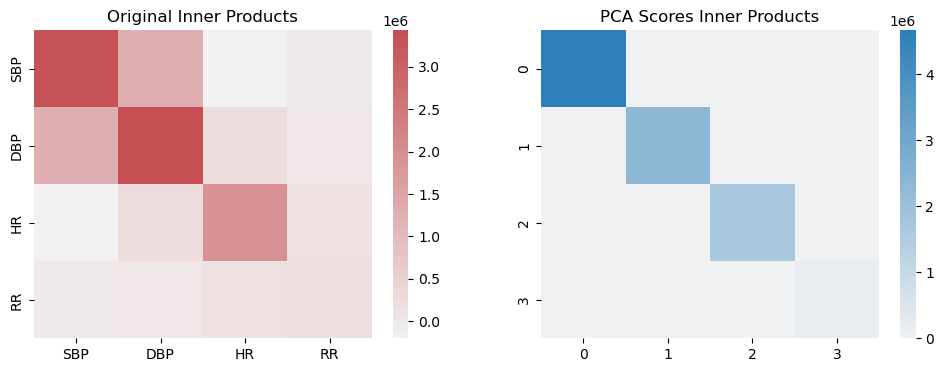

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(X_centered.T @ X_centered,
    cmap=sns.light_palette("#c44e52", as_cmap=True),
    ax=axes[0]).set_title("Original Inner Products")

sns.heatmap(X_pca.T @ X_pca,
    cmap=sns.light_palette("#2c7fb8", as_cmap=True),
    ax=axes[1]).set_title("PCA Scores Inner Products")

- So the covariance between DBP and SBP is eliminated
- But also, we have no clue what the new transformed variables mean; they're just vectors that correspond to high variation in the original space
- But these new vectors are mutually orthogonal, so we no longer have multicolinearity and quite the same overfitting dangers as before

# 2. Principal Components Regression

## PCA and Multicolinearity
This is great:

1. The transformed values of $X$ into $X_{pca}$ are de-correlated or orthogonal to one another
2. The PCA-transformed values are ranked from "most explanatory" to "least explanatory" by their eigenvalues
3. We can just pick how many of the PCA-transformed columns to include in a regression, and not worry about variable selection or multicolinearity

## An Alternative to Regularization
Imagine we do the following:

1. Run PCA on the data $X$
2. Fit $K<L$ variables using the PCA decomposition of the data matrix, 
3. Run `Z = pca.transform(X)` to get the PCA transformed values of $X$, which equals `Z = (X-X.mean()) @ P` where $P$ is the matrix of the $K$ eigenvectors corresponding to the $K$ largest eigenvalues
3. Run a linear or logistic regression of $y$ on $Z$

This is appealing:

1. The principal components are orthogonal by construction, reducing multicolinearity concerns
2. We're doing a kind of regularization/shrinkage by throwing away extraneous variables, similar to LASSO
3. We know exactly how much variation in the original data is retained

This is called **Principal Components Regression**, and is extremely popular

## Exercise: Revisiting Golub
1. Load the `golub.csv` data, clean the outcome variable, and $z$-score normalize the gene values.
2. Fit a Lasso regression, with the penalty selected by 10-fold cross validation on the training folds.
3. Conduct PCA on the normalized gene scores. For each number of retained principal components, track the reconstruction $R^2$.
4. Run principal components regression (PCR) of the outcome on the principal-component scores, and evaluate it with 10-fold cross validation.
5. Compare the predictive performance of Lasso and PCR. Which predicts better? Which is easier to interpret?

In [5]:
# 1. 
df = pd.read_csv('./data/golub.csv')
mapper = {'allB': 0, 'allT': 0, 'aml': 1}
df['outcome'] = df['cancer'].map(mapper)

y = df['outcome'].to_numpy(dtype=float)
X = df.drop(['Samples', 'BM.PB', 'Gender', 'Source', 'tissue.mf', 'cancer', 'outcome'],
    axis=1)

scaler_full = StandardScaler() # z-score normalize the genes
X_sc = scaler_full.fit_transform(X)

print(f'Observations: {X_sc.shape[0]}')
print(f'Genes: {X_sc.shape[1]}')

Observations: 72
Genes: 7129


In [6]:
# 2. Lasso
alpha_grid = np.logspace(-3, -2, num=50)
model = LassoCV(cv=10, 
                max_iter=10_000,
                alphas=alpha_grid,
                random_state=100)
lasso = model.fit(X_sc, y)

index_star = np.argmin( np.median(lasso.mse_path_,axis=1) )
alpha_star = lasso.alphas_[index_star]
y_hat_lasso = lasso.predict(X_sc)

Optimal cost hyperparameter: 0.003727593720314938


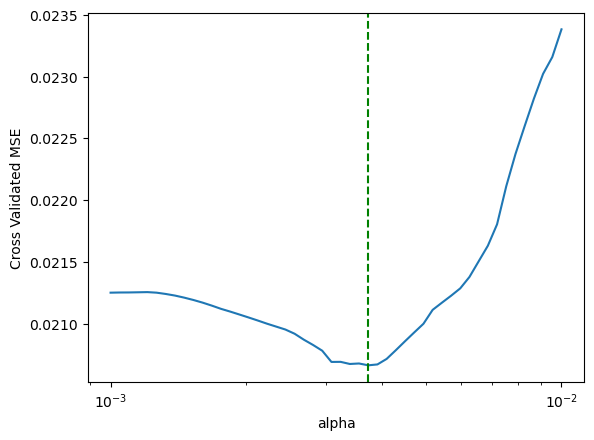

In [7]:
sns.lineplot( x=lasso.alphas_, y= np.median(lasso.mse_path_,axis=1) )
plt.axvline(x=alpha_star, color='green', linestyle='--', 
            linewidth=1.5)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross Validated MSE")
print(f'Optimal cost hyperparameter: {alpha_star}')

In [8]:
# 3. Run PCA
K = min(X_sc.shape)
pca = PCA(n_components=K)
X_pca = pca.fit_transform(X_sc)
P = pca.components_.T

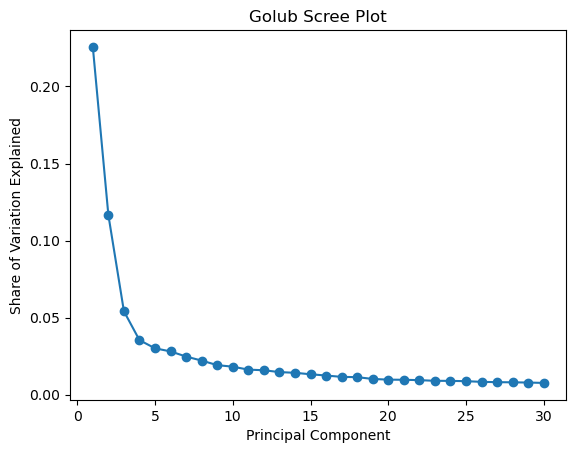

In [9]:
# Scree plot:
grid = np.arange(1, 31)
y_scree = pca.explained_variance_ratio_[:30]
plt.plot(grid, y_scree, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Share of Variation Explained")
plt.title('Golub Scree Plot')
plt.show()

Text(0.5, 1.0, 'Golub PCA Reconstruction')

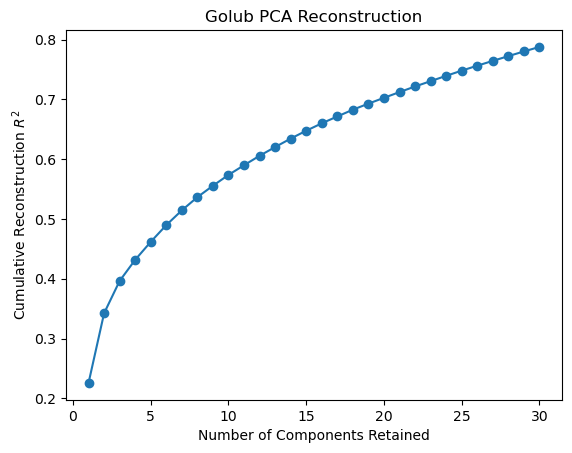

In [10]:
# Reconstruction R^2 plot:
grid = np.arange(1, 31)
y_recon = np.cumsum(pca.explained_variance_ratio_)[:30]
plt.plot(grid, y_recon, marker='o')
plt.xlabel("Number of Components Retained")
plt.ylabel("Cumulative Reconstruction $R^2$")
plt.title('Golub PCA Reconstruction')

- The first few principal components already explain a lot, but the curve is fairly gradual here.
- In this data set, about 57% of the standardized gene variation is captured by the first 10 components, about 70% by the first 20, and about 79% by the first 30.

Text(0.5, 1.0, 'First 20 PC Scores: Diagonal')

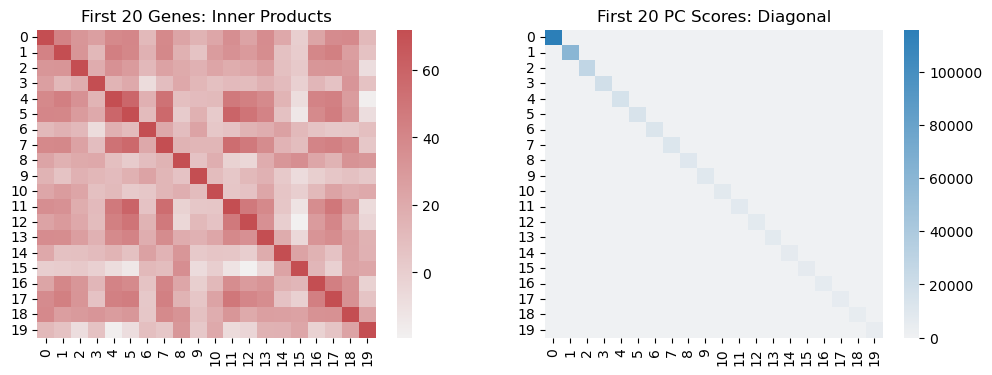

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap( X_sc[:, :20].T @ X_sc[:, :20],
    cmap=sns.light_palette("#c44e52", as_cmap=True),
    ax=axes[0])
axes[0].set_title("First 20 Genes: Inner Products")
sns.heatmap(X_pca[:, :20].T @ X_pca[:, :20],
    cmap=sns.light_palette("#2c7fb8", as_cmap=True),
    ax=axes[1])
axes[1].set_title("First 20 PC Scores: Diagonal")

- So PCA is really doing something: The off-diagonal covariances are being driven to zero, and only the on-diagonal self-covariances remain

In [ ]:
# 4. PCR

mse = lambda y_true, y_hat: np.mean((y_true-y_hat)**2)
kf = KFold(n_splits=10, # Create 10-fold split
           shuffle=True,
           random_state=100)
X_np = X.to_numpy(dtype=float)
alpha_grid = np.logspace(-4, -1, num=50)

# Results storage:
mse_pcr = []
mse_lasso = []
rsq_pcr = []
rsq_lasso = []

K_max = 60 # Max number of components

for train_idx, test_idx in kf.split(X_np):
    # Split data
    X_train = X_np[train_idx]
    X_test = X_np[test_idx]
    y_train = y[train_idx]
    y_test = y[test_idx]
    mse_mean = mse(y_test, np.mean(y_train))

    # 1. z-scale, PCA the data, transform
    X_train_mean = X_train.mean()
    X_train_sd = X_train.std()
    X_train_mean = X_train.mean(axis=0)
    X_train_sd = X_train.std(axis=0, ddof=0)
    X_train_sd[X_train_sd == 0] = 1
    Z_train = (X_train - X_train_mean) / X_train_sd
    Z_test  = (X_test  - X_train_mean) / X_train_sd

    pca = PCA(n_components=K_max)
    Z_train_pca = pca.fit_transform(Z_train)
    Z_test_pca = pca.transform(Z_test)
    
    # 2. PC Regression for various k values
    inner_mse_pcr = []
    inner_rsq_pcr = []
    for k in range(1,K_max,1):
        reg = LinearRegression()
        reg.fit(Z_train_pca[:,:k],y_train)
        y_hat_pcr_k = reg.predict(Z_test_pca[:,:k])
        mse_pcr_k = mse(y_test, y_hat_pcr_k)
        inner_mse_pcr.append(mse_pcr_k)
        inner_rsq_pcr.append(1 - mse_pcr_k/mse_mean)
    # Save median inner results to outer
    mse_pcr.append(inner_mse_pcr)
    rsq_pcr.append(inner_rsq_pcr)

    # Lasso for comparison
    lasso_k = LassoCV(cv=5,
        max_iter=10_000,
        alphas=alpha_grid,
        random_state=100)
    lasso_k.fit(Z_train, y_train)
    y_hat_lasso = lasso_k.predict(Z_test)
    mse_lasso_fold = mse(y_test, y_hat_lasso)
    mse_lasso.append( mse_lasso_fold )
    rsq_lasso.append( 1 - mse_lasso_fold/mse_mean ) 

median_mse_pcr = np.median( np.array(mse_pcr), axis = 0)
median_rsq_pcr = np.median( np.array(rsq_pcr), axis = 0)
median_mse_lasso = np.median(mse_lasso)
median_rsq_lasso = np.median(rsq_lasso)

Text(0, 0.5, 'R-squared')

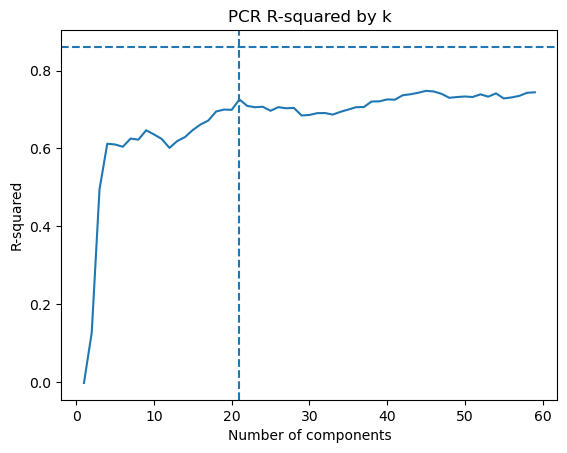

In [14]:
sns.lineplot( x=np.arange(1,K_max,1), 
             y=median_rsq_pcr).set(title='PCR R-squared by k')
plt.axhline(y=median_rsq_lasso, linestyle='--')
k_star = np.argmin(median_mse_pcr) + 1
plt.axvline(k_star, linestyle='--')
plt.xlabel('Number of components')
plt.ylabel('R-squared')

Text(0, 0.5, 'MSE')

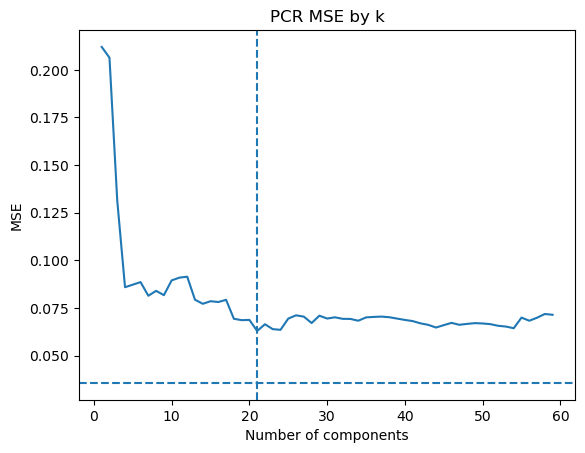

In [15]:
sns.lineplot( x=np.arange(1,K_max,1), 
             y=median_mse_pcr).set(title='PCR MSE by k')
plt.axhline(y=median_mse_lasso, linestyle='--')
k_star = np.argmin(median_mse_pcr) + 1
plt.axvline(k_star, linestyle='--')
plt.xlabel('Number of components')
plt.ylabel('MSE')

## Explainability/Interpretability

- PCR is usually less interpretable than Lasso because each principal component is itself a mixture of many genes; but is it really a "black box" method?
- If `Z = (X - xbar) @ P`, and we regress `y` on `Z`, then the fitted values are
$$
\hat{y} = a + Zg = a + (X - \bar{x})Pg.
$$
- Rearranging gives
$$
\hat{y} = (a - \bar{x}Pg) + X(Pg),
$$
so the implied coefficient vector back in the original gene space is `b_hat = P @ g`.
- That means PCR can still be written as a linear model in the original variables, but the coefficients are usually dense (mostly non-zero) rather than sparse (mostly zero, like Lasso), which makes scientific interpretation harder.

## Conclusion
- Lasso, Ridge, and PCR are all extremely powerful predictive analytics tools, in their linear or logistic forms
- PCA turns a correlated feature matrix into orthogonal principal-component scores
- PCR is attractive when we want to compress many correlated variables into a smaller orthogonal basis for regression
- PCA is unsupervised, so the directions with the most variance are not always the directions most useful for predicting y: That's how Lasso beat PCR, even though PCR is a first-class tool as well
- Lasso is usually easier to explain because it can set many coefficients exactly to zero, while PCR mixes information across many original variables
- Principal Components Regression unifies a lot of the ideas across ML1 and Math for Data Science: Linear algebra, regression, feature selection, multicolinearity, etc.
- If you get the point where you've mastered everything in this lecture, you're really ready to move on to more advanced machine learning, like neural networks 